# Scattering statistics on a spherical subdomain

Sea surface temperature over the Bay of Biscay, projected onto a HEALPix
subdomain, analysed with the scattering covariance and then emulated.

This is the STL port of the `local_foscat` demonstration from
[IAOCEA/demo-foscat-pangeo-eosc](https://github.com/IAOCEA/demo-foscat-pangeo-eosc),
originally written by Jean-Marc Delouis, Tina Odaka and Justus Mangin
(LOPS — Laboratoire d'Océanographie Physique et Spatiale, UMR 6523
CNRS-IFREMER-IRD-Univ. Brest), with support from CNES.

## What it shows

Earth observation rarely gives you the whole sphere. The interesting field
covers a patch, at a resolution where the full sphere would be far too large to
hold — here `nside = 2048`, which would be 50 million pixels for 21 000 useful
ones. Everything below therefore runs on a **partial sky**, described by its
`cell_ids`:

1. project a lat/lon model output onto HEALPix cells;
2. smooth it, and take the directional wavelet transform scale by scale;
3. compute the scattering covariance, and compare it with white noise;
4. emulate new fields that share those statistics.

## What differs from the FOSCAT original

The pipeline is the same; the API is STL's, and the spherical geometry comes
from [`healpix-analyse`](https://github.com/GRID4EARTH/healpix-analyse) rather
than from FOSCAT:

| FOSCAT | STL |
|---|---|
| `sc.funct(BACKEND='torch')` | `STL_Healpix_Kernel_Torch` + `get_wavelet_op()` |
| `scat.smooth(...)` | `wav_op.apply_smooth(...)` |
| `scat.convol(...)` | `wav_op.apply(data, j)` |
| `scat.ud_grade_2(...)` | `wav_op.downsample(data, dg)` |
| `scat.eval(..., norm='auto')` | `st_op.apply(data, norm='store_ref')` |
| `synthe.Loss` + `synthe.Synthesis` | `synthesize_from_maps(...)` |
| `foscat.HealSpline` for the regridding | `healpix_resample.BilinearResampler` |

**Runtime**: a few minutes, dominated by the emulation at the end. `N_MAPS` and
`MAX_ITER` are the two knobs.

## 1. Packages

In [1]:
%matplotlib inline

import os
import sys
import warnings

import numpy as np
import torch
import healpy as hp
import matplotlib.pyplot as plt

# --- walk up to the repository root (the directory holding STL_main) ---
ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "STL_main")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        raise RuntimeError("STL_main directory not found above %s" % os.getcwd())
    ROOT = parent
sys.path.insert(0, ROOT)

DATA_TEST_PATH = os.path.join(ROOT, "data", "test")
warnings.filterwarnings("ignore", category=UserWarning)

from healpix_resample import BilinearResampler

from STL_main.STL_Healpix_Kernel_Torch import STL_Healpix_Kernel_Torch as DataClass
from STL_main.Synthesis import synthesize_from_maps

torch.manual_seed(0)
np.random.seed(0)

print("repository root:", ROOT)

repository root: /home/jovyan/STL-Dev


## 2. The data

Hourly ocean fields for the Iberia–Biscay–Ireland region (NEMO 3.6, Copernicus
Marine Service). A single hour at the surface is enough here.

The cell tries the public zarr store first, and falls back on the extract
shipped with STL — a single time step, 78 kB — when the store is unreachable.
Land is `NaN` in the source and is simply dropped: those points never become
HEALPix cells.

source : zarr store (https://data-taos.ifremer.fr/EGU25_CFOSAT/MARS_SST_EX.zarr)
grid   : 180 x 324, 59.8 % ocean
extent : lat 46.03..51.00, lon -8.00..0.97
SST    : 8.05 .. 13.37 degC


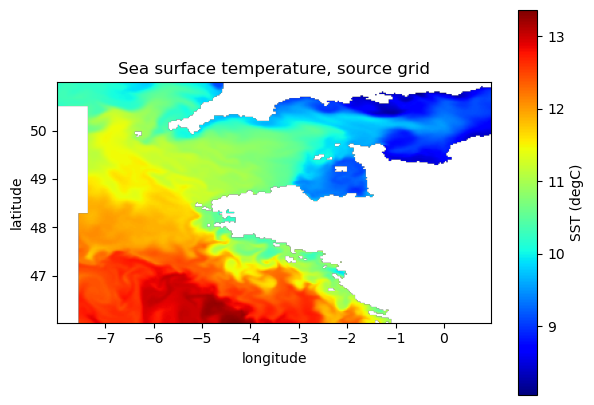

In [2]:
ZARR_URL = "https://data-taos.ifremer.fr/EGU25_CFOSAT/MARS_SST_EX.zarr"
LOCAL_NPZ = os.path.join(DATA_TEST_PATH, "MARS_SST_EX.npz")

sst = latitude = longitude = None
try:
    import xarray as xr

    ds = xr.open_zarr(ZARR_URL)
    sst = ds.thetao.isel(time=12, depth=0).compute().values
    latitude = ds.latitude.compute().values
    longitude = ds.longitude.compute().values
    origin = "zarr store (%s)" % ZARR_URL
except Exception as exc:  # offline, or the store moved
    print("remote store unavailable (%s: %s)" % (type(exc).__name__, str(exc)[:80]))
    bundle = np.load(LOCAL_NPZ)
    sst, latitude, longitude = bundle["sst"], bundle["latitude"], bundle["longitude"]
    origin = "local extract (%s)" % os.path.relpath(LOCAL_NPZ, ROOT)

print("source :", origin)
print("grid   : %d x %d, %.1f %% ocean" % (*sst.shape, 100 * np.isfinite(sst).mean()))
print("extent : lat %.2f..%.2f, lon %.2f..%.2f"
      % (latitude.min(), latitude.max(), longitude.min(), longitude.max()))
print("SST    : %.2f .. %.2f degC" % (np.nanmin(sst), np.nanmax(sst)))

plt.figure(figsize=(7, 5))
plt.imshow(sst, origin="lower", cmap="jet",
           extent=[longitude.min(), longitude.max(), latitude.min(), latitude.max()])
plt.colorbar(label="SST (degC)")
plt.xlabel("longitude"); plt.ylabel("latitude")
plt.title("Sea surface temperature, source grid")
plt.show()

## 3. Onto the HEALPix grid

`nside = 2048` gives 1.7 arcmin cells, which matches the ~0.028 degree spacing
of the source grid. The patch then covers about 21 000 cells out of the 50
million a full sphere would have — the whole point of working with `cell_ids`.

The FOSCAT demo used `foscat.HealSpline` to fit a spline through the source
points. Here the resampling is done with
[`healpix-resample`](https://pypi.org/project/healpix-resample/), whose
resamplers return the values **together with the local `cell_ids`** they landed
on — exactly the pair STL expects, with no full-sphere array ever allocated.

`BilinearResampler` interpolates from the four nearest source samples, which
matters here: the source spacing and the cell size are close enough (both about
1.7 arcmin) that plain binning would leave scattered empty cells inside the
domain. The same package offers `BicubicResampler`, `KNeighborsResampler`,
`ConservativeResampler` and `GroupByResampler` behind the same interface —
`GroupByResampler(reduce="mean")` is the plain-binning one, and is the right
choice when the source grid is much finer than the target cells.

`ellipsoid="sphere"` keeps the pixelisation consistent with the spherical
geometry used by the convolutions and by the harmonic transform further down.

In [3]:
NSIDE = 2048
LEVEL = int(np.log2(NSIDE))

lon_grid, lat_grid = np.meshgrid(longitude, latitude)
ocean = np.isfinite(sst)

resampler = BilinearResampler(
    lon_deg=-lon_grid[ocean].astype(np.float64),
    lat_deg=lat_grid[ocean].astype(np.float64),
    level=LEVEL,
    nest=True,
    ellipsoid="sphere",
    device="cpu",
    verbose=False,
)
resampled = resampler.resample(sst[ocean].astype(np.float64))

cell_ids = np.asarray(resampled.cell_ids)
values = np.asarray(resampled.cell_data)

print("nside %d -> %.2f arcmin per cell" % (NSIDE, hp.nside2resol(NSIDE, arcmin=True)))
print("%d source points -> %d cells (%.2f point per cell)"
      % (ocean.sum(), cell_ids.size, ocean.sum() / cell_ids.size))
print("full sphere would be %d pixels; the patch uses %.4f %% of them"
      % (12 * NSIDE**2, 100 * cell_ids.size / (12 * NSIDE**2)))

# the field the statistics work on: the median is not informative here
median = np.median(values)
field = values - median

nside 2048 -> 1.72 arcmin per cell
34876 source points -> 22706 cells (1.54 point per cell)
full sphere would be 50331648 pixels; the patch uses 0.0451 % of them


<Figure size 700x600 with 0 Axes>

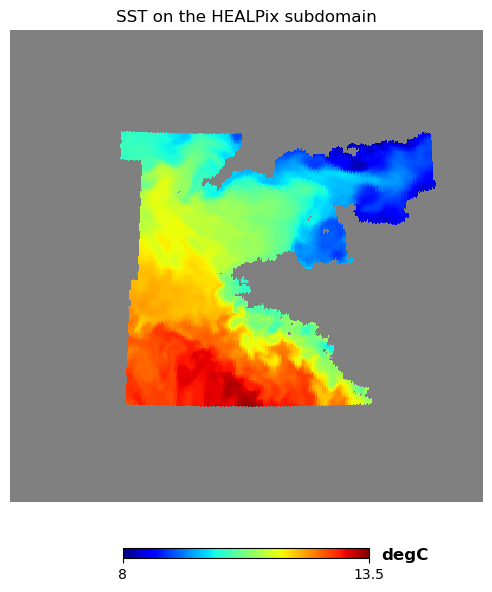

In [4]:
# view centred on the patch
# The centre has to come from the mean *direction*, not from the mean of the
# angles: this domain straddles longitude 0.
vec = np.asarray(hp.pix2vec(NSIDE, cell_ids, nest=True))
centre = vec.mean(axis=1)
centre /= np.linalg.norm(centre)
theta_0, phi_0 = hp.vec2ang(centre)
ROT = [np.rad2deg(phi_0[0]), 90.0 - np.rad2deg(theta_0[0])]

XSIZE = 400
radius = np.rad2deg(np.arccos(np.clip(centre @ vec, -1.0, 1.0))).max()
RESO = 60 * 2.1 * radius / XSIZE  # arcmin per screen pixel, with a small margin


def plot_patch(values, ids=None, nside=None, sub=None, hold=False, title=None,
               unit=None, vmin=None, vmax=None, cmap="jet"):
    """Show a partial-sky field on a gnomonic projection centred on the patch."""
    ids = cell_ids if ids is None else np.asarray(ids)
    nside = NSIDE if nside is None else nside

    full = np.full(12 * nside**2, hp.UNSEEN)
    values = np.asarray(values)
    full[ids] = np.where(np.isfinite(values), values, hp.UNSEEN)

    hp.gnomview(full, cmap=cmap, nest=True, rot=ROT, reso=RESO, hold=hold, sub=sub,
                xsize=XSIZE, notext=True, title=title, unit=unit,
                min=vmin, max=vmax)


plt.figure(figsize=(7, 6))
plot_patch(values, vmin=8, vmax=13.5, title="SST on the HEALPix subdomain",
           unit="degC")
plt.show()

## 4. The STL operator

One object carries the field and its geometry — resolution, pixel indices,
partial sky. `pbc` comes out `False` on its own: this is not a full sphere.

In [5]:
J, L, KERNELSZ = 5, 4, 5

data = DataClass(field, nside=NSIDE, cell_ids=cell_ids)
print("DT      :", data.DT)
print("N0 / dg :", data.N0, "/", data.dg)
print("pbc     :", data.pbc, "(partial sky)")
print("pixels  :", data.array.shape[-1])

wav_op = data.get_wavelet_op(J=J, L=L, kernel_size=KERNELSZ)
print("\nJ = %d | L = %d | KERNELSZ = %d" % (wav_op.J, wav_op.L, wav_op.KERNELSZ))

DT      : HealpixKernel_torch
N0 / dg : (2048,) / 0
pbc     : False (partial sky)
pixels  : 22706

J = 5 | L = 4 | KERNELSZ = 5


## 5. Smoothing

Multiscale analysis starts with a low-pass. On a partial sky the convolution has
to know where the domain stops, which is what `cell_ids` gives it — the stencil
weights of missing neighbours are renormalised away rather than treated as
zeros.

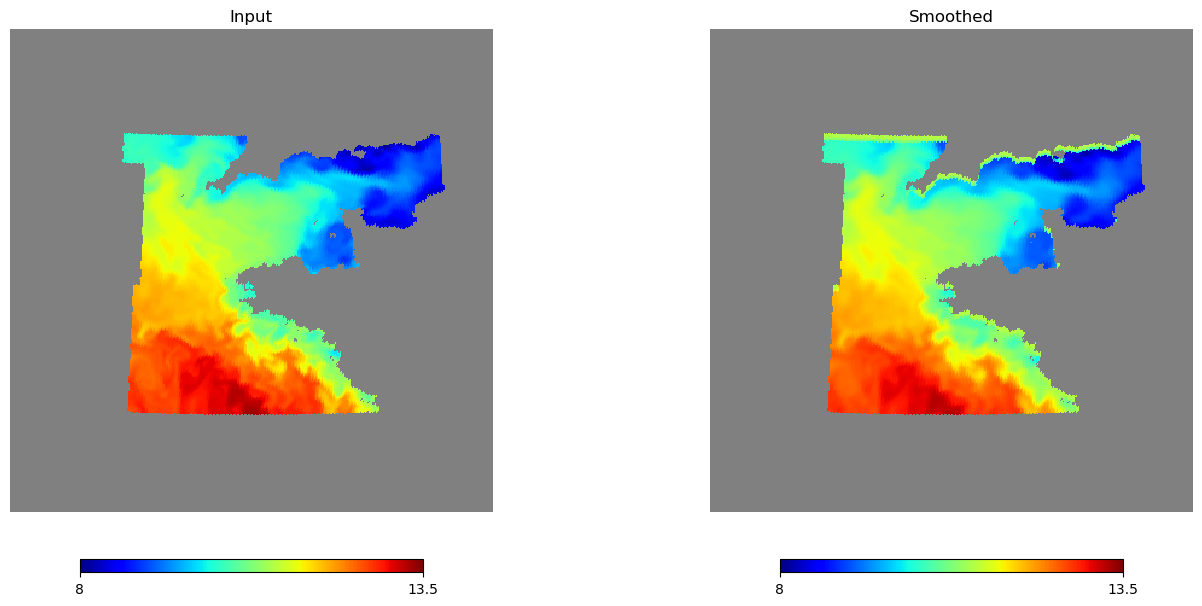

In [6]:
smoothed = wav_op.apply_smooth(data, inplace=False)

plt.figure(figsize=(14, 6))
plot_patch(field + median, sub=(1, 2, 1), title="Input", vmin=8, vmax=13.5)
plot_patch(smoothed.array.cpu().numpy() + median, sub=(1, 2, 2), title="Smoothed",
           vmin=8, vmax=13.5)
plt.show()

## 6. The wavelet decomposition

The heart of the scattering covariance. `apply(data, j)` returns the complex
response of the `L` oriented wavelets at the current resolution; below, the real
part, the imaginary part and the modulus at the finest scale $J_0$.

wavelet coefficients: (4, 22706) complex128


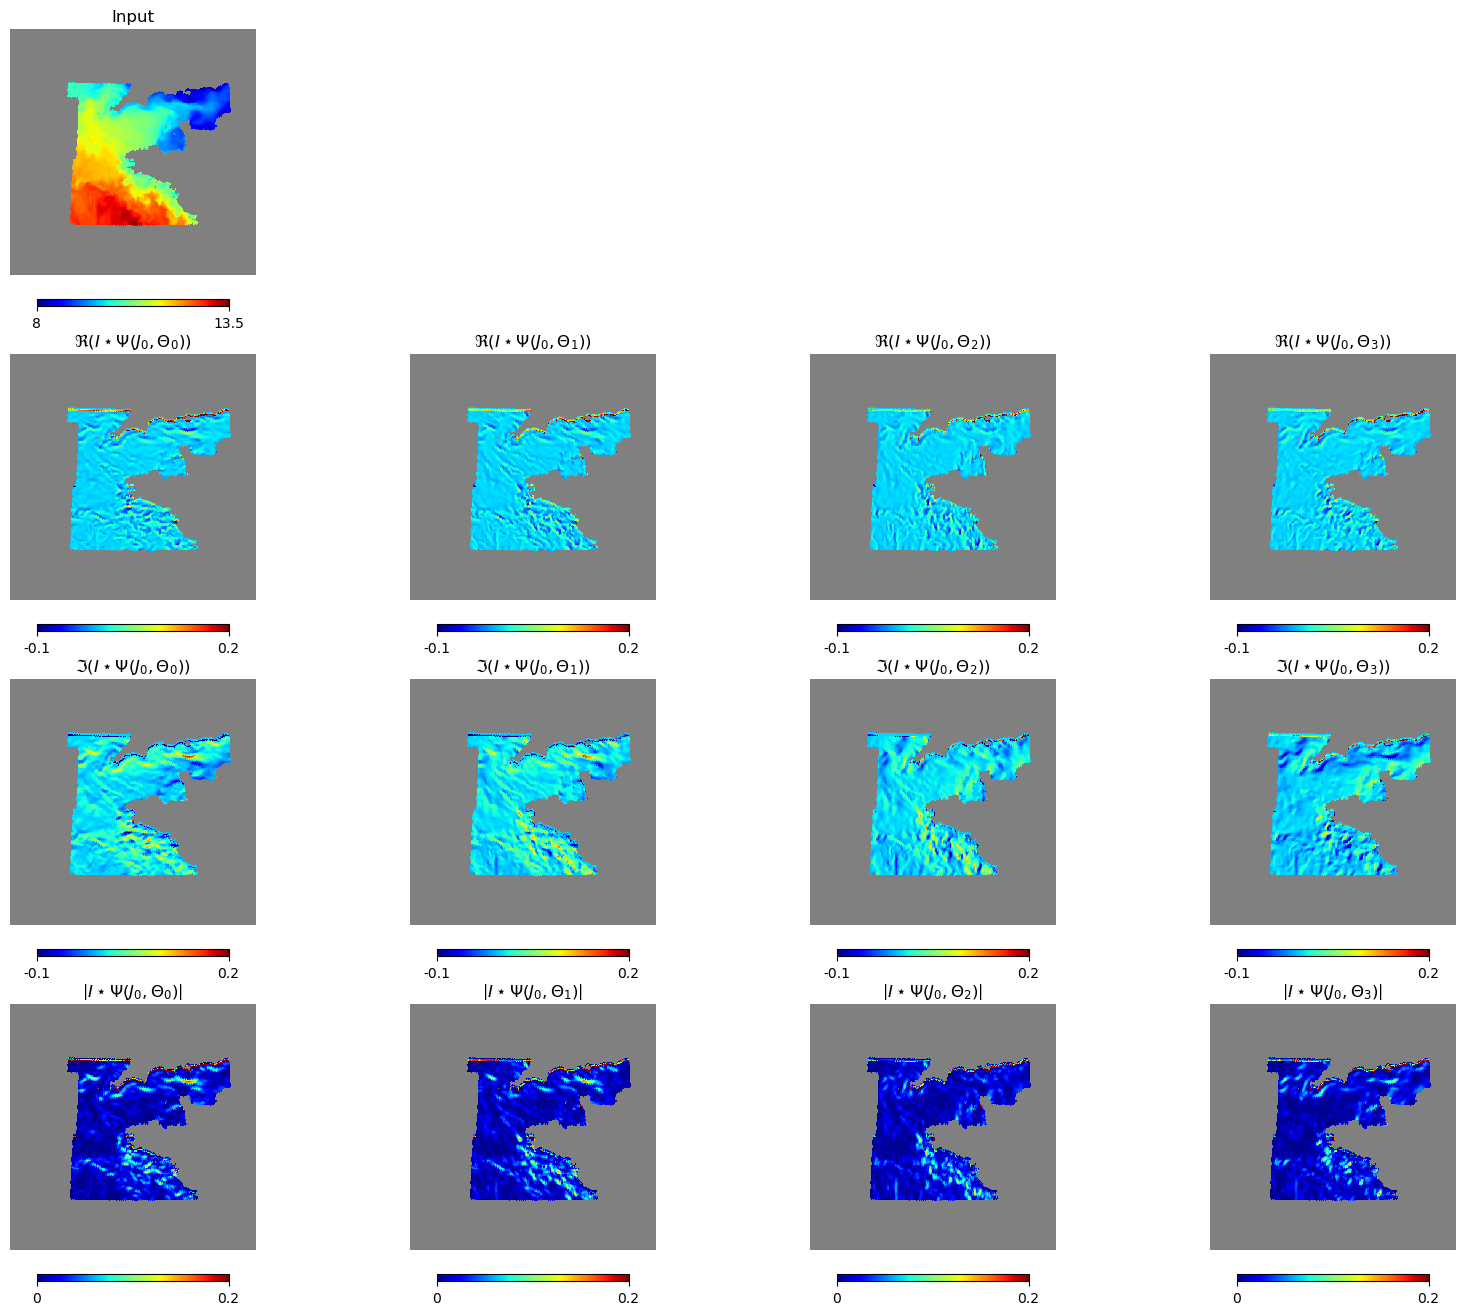

In [7]:
wave = wav_op.apply(data, 0).array.cpu().numpy()
print("wavelet coefficients:", wave.shape, wave.dtype)

plt.figure(figsize=(16, 13))
plot_patch(field + median, sub=(4, 4, 1), title="Input", vmin=8, vmax=13.5)
for k in range(L):
    plot_patch(wave[k].real, sub=(4, 4, 5 + k), vmin=-0.1, vmax=0.2,
               title=r"$\Re\left(I\star\Psi(J_0,\Theta_%d)\right)$" % k)
    plot_patch(wave[k].imag, sub=(4, 4, 9 + k), vmin=-0.1, vmax=0.2,
               title=r"$\Im\left(I\star\Psi(J_0,\Theta_%d)\right)$" % k)
    plot_patch(np.abs(wave[k]), sub=(4, 4, 13 + k), vmin=0, vmax=0.2,
               title=r"$\left|I\star\Psi(J_0,\Theta_%d)\right|$" % k)
plt.show()

### Across the scales

Each scale is computed at its own resolution: the field is decimated between
scales, so scale $J_1$ costs a quarter of $J_0$, and so on. `downsample` returns
both the coarser field and its new `cell_ids`.

scale J_1 ->   5914 cells at nside 1024
scale J_2 ->   1578 cells at nside  512
scale J_3 ->    437 cells at nside  256
scale J_4 ->    132 cells at nside  128


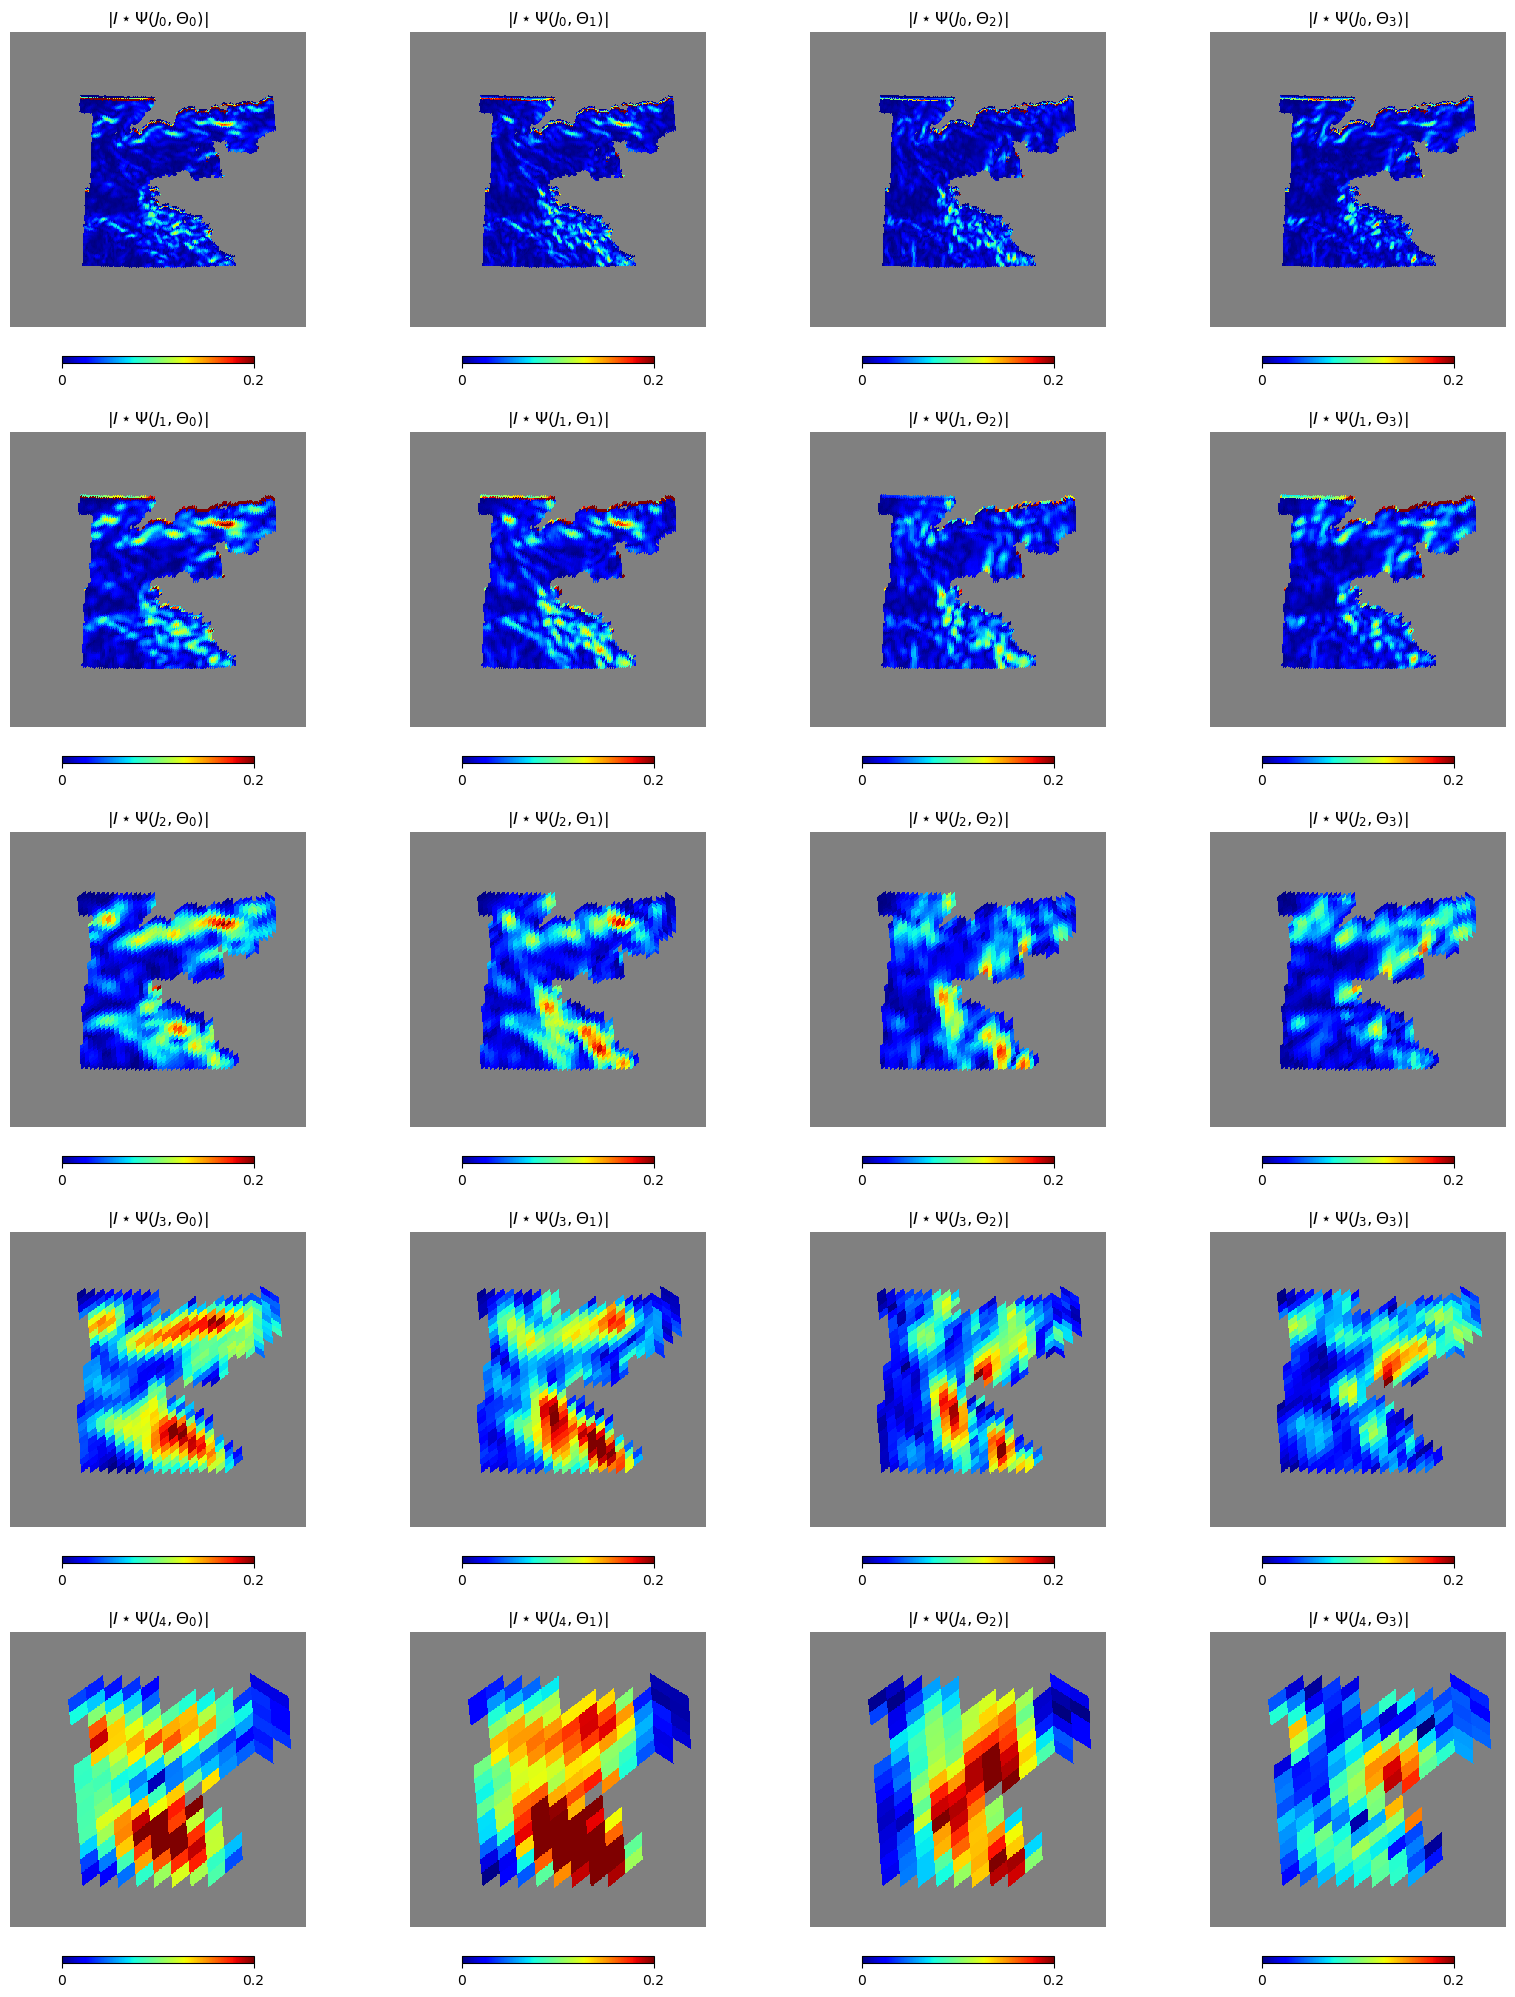

In [8]:
current = data.copy()

plt.figure(figsize=(16, 4 * J))
for j in range(J):
    coeffs = wav_op.apply(current, j).array.cpu().numpy()
    ids = current.cell_ids.cpu().numpy()
    for k in range(L):
        plot_patch(np.abs(coeffs[k]), ids=ids, nside=current.nside,
                   sub=(J, L, 1 + k + L * j), vmin=0, vmax=0.2,
                   title=r"$|I\star\Psi(J_%d,\Theta_%d)|$" % (j, k))
    if j < J - 1:
        current = wav_op.downsample(current, j + 1, inplace=False)
        print("scale J_%d -> %6d cells at nside %4d"
              % (j + 1, current.array.shape[-1], current.nside))
plt.show()

## 7. Scattering covariance, against white noise

The comparison the original makes: the same statistics computed on the SST field
and on Gaussian noise of the same variance. If the two agreed, the field would
carry no structure beyond its variance — they do not, by orders of magnitude on
S3 and S4, which is exactly what a turbulent sea surface should give.

The angular power spectrum is switched off here (`compute_PS=False`): at
`nside = 2048` the spherical harmonic transform would run to $\ell = 6143$ over
the whole sphere, for a patch covering 0.04 % of it.

In [16]:
st_op = data.get_ST_op(J=J, L=L, compute_PS=False)

st_data = st_op.apply(DataClass(field, nside=NSIDE, cell_ids=cell_ids),
                      norm="store_ref")

noise = np.random.randn(field.size) * field.std()
st_noise = st_op.apply(DataClass(noise, nside=NSIDE, cell_ids=cell_ids),
                       norm="load_ref")

print("coefficients per family:",
      {n: tuple(getattr(st_data, n).shape) for n in ("S1", "S2", "S3", "S4")})

coefficients per family: {'S1': (1, 1, 1, 5, 4), 'S2': (1, 1, 1, 5, 4), 'S3': (1, 1, 1, 5, 5, 4, 4), 'S4': (1, 1, 1, 5, 5, 5, 4, 4, 4)}


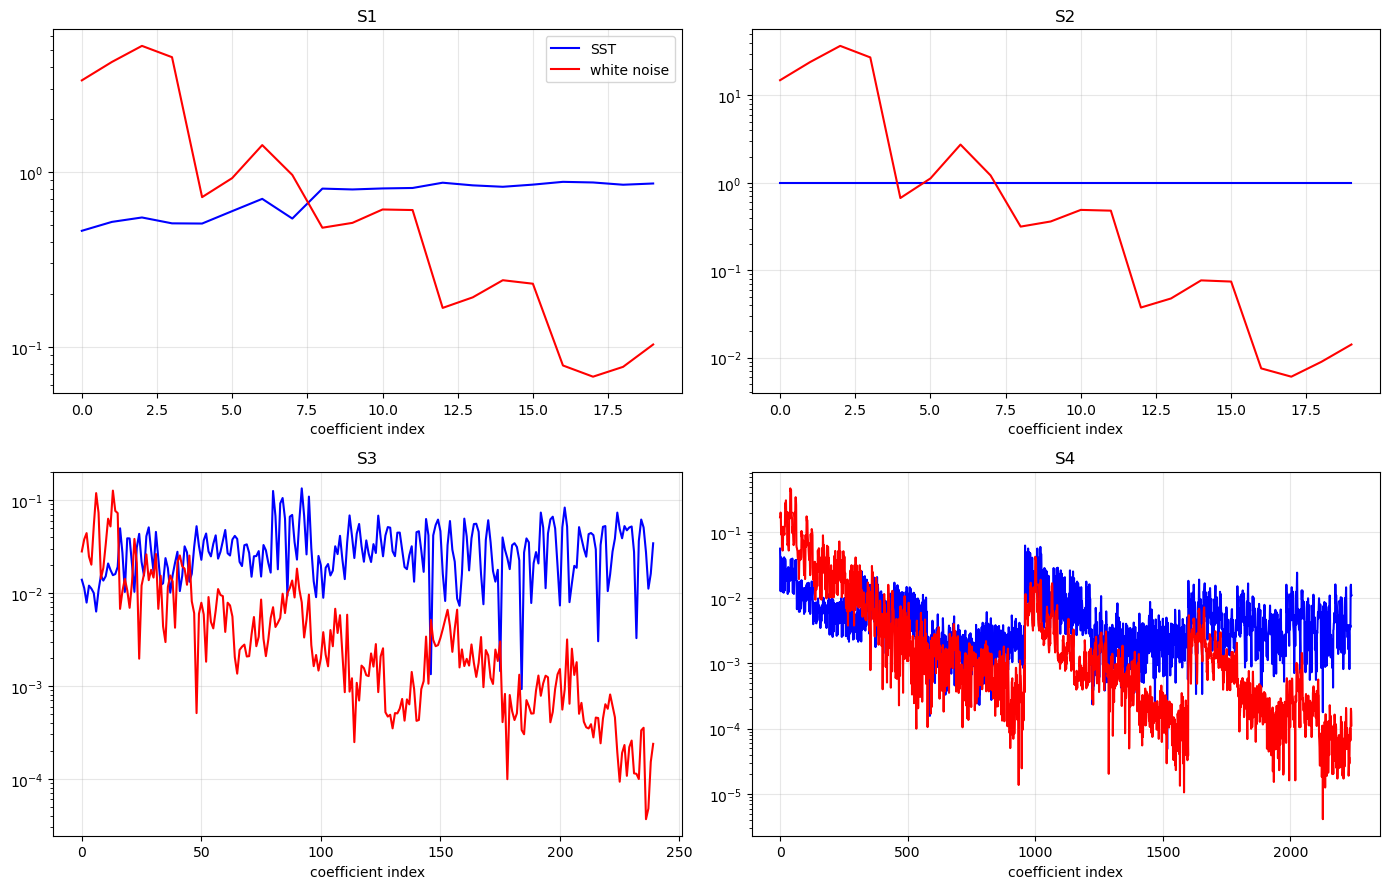

In [17]:
def finite(x):
    x = np.asarray(x).flatten()
    return x[np.isfinite(x)]


plt.figure(figsize=(14, 9))
for idx, name in enumerate(("S1", "S2", "S3", "S4")):
    plt.subplot(2, 2, 1 + idx)
    plt.plot(finite(getattr(st_data, name).abs().cpu().numpy()), color="b",
             label="SST")
    plt.plot(finite(getattr(st_noise, name).abs().cpu().numpy()), color="r",
             label="white noise")
    plt.yscale("log"); plt.title(name); plt.grid(alpha=.3)
    plt.xlabel("coefficient index")
    if idx == 0:
        plt.legend()
plt.tight_layout(); plt.show()

## 8. Emulation

Several fields are drawn at once, all starting from a heavily smoothed version
of the target plus a little noise, and pushed until their scattering statistics
match the target's. The result is not the target: it is a different field with
the same statistics, which is what an emulator should produce.

`N_MAPS` and `MAX_ITER` set the cost. The original demo used 40 maps and 500
epochs; the values below keep the notebook to a few minutes.

In [23]:
N_MAPS = 4
MAX_ITER = 200

# a heavily smoothed version of the target, as the starting point
start = data.copy()
for _ in range(6):
    start = wav_op.apply_smooth(start, inplace=False)
start = start.array.cpu().numpy()

initial = start[None, :] + np.random.randn(N_MAPS, field.size) * field.std() * 0.1

print("target std %.3f | starting std %.3f" % (field.std(), initial.std()))

target std 1.258 | starting std 0.843


In [24]:
emulated = synthesize_from_maps(
    data,
    nbatch=N_MAPS,
    pbc_running=False,
    compute_PS=False,
    init_running=initial[:, None, :],   # (N_MAPS, 1, Npix)
    max_iter=MAX_ITER,
    print_iter=10,
    seed=26,
)
emulated = emulated.detach().cpu().numpy()
print("emulated:", emulated.shape)

Running synthesis on device: cuda:0 dtype: torch.float64
Initial shape for u: (4, 1, 22706)
Synthesis on 11354 ST coefficients
[LBFGS] iter 10, loss = 1.925573e+01
[LBFGS] iter 20, loss = 1.806016e+00
[LBFGS] iter 30, loss = 4.355548e-01
[LBFGS] iter 40, loss = 1.762641e-01
[LBFGS] iter 50, loss = 9.059207e-02
[LBFGS] iter 60, loss = 4.476064e-02
[LBFGS] iter 70, loss = 2.363247e-02
[LBFGS] iter 80, loss = 1.389106e-02
[LBFGS] iter 90, loss = 8.331680e-03
[LBFGS] iter 100, loss = 5.651162e-03
[LBFGS] iter 110, loss = 3.803394e-03
[LBFGS] iter 120, loss = 2.553733e-03
[LBFGS] iter 130, loss = 1.881096e-03
[LBFGS] iter 140, loss = 1.355653e-03
[LBFGS] iter 150, loss = 1.030963e-03
[LBFGS] iter 160, loss = 7.925170e-04
[LBFGS] iter 170, loss = 6.241393e-04
[LBFGS] iter 180, loss = 5.064858e-04
[LBFGS] iter 190, loss = 4.274609e-04
[LBFGS] iter 200, loss = 3.551677e-04
209 iterations of synthesis.
Execution time: 82.563 s
emulated: (4, 22706)


### The maps

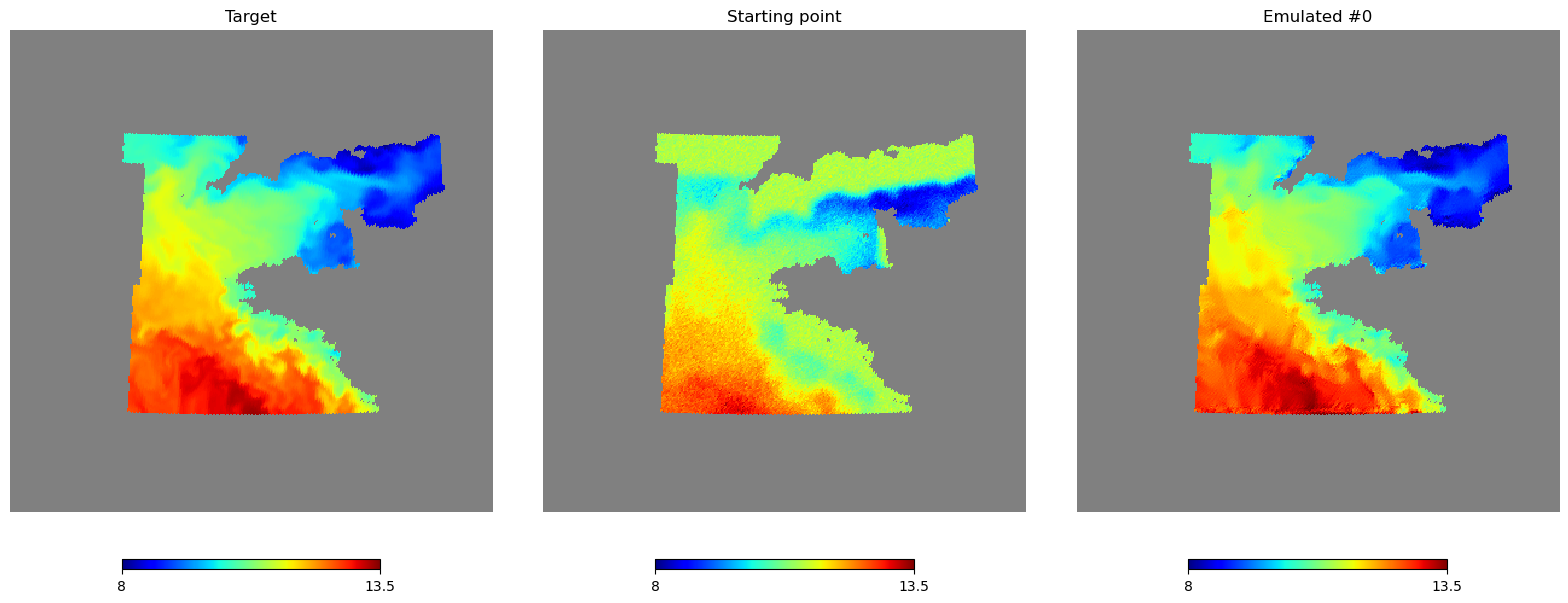

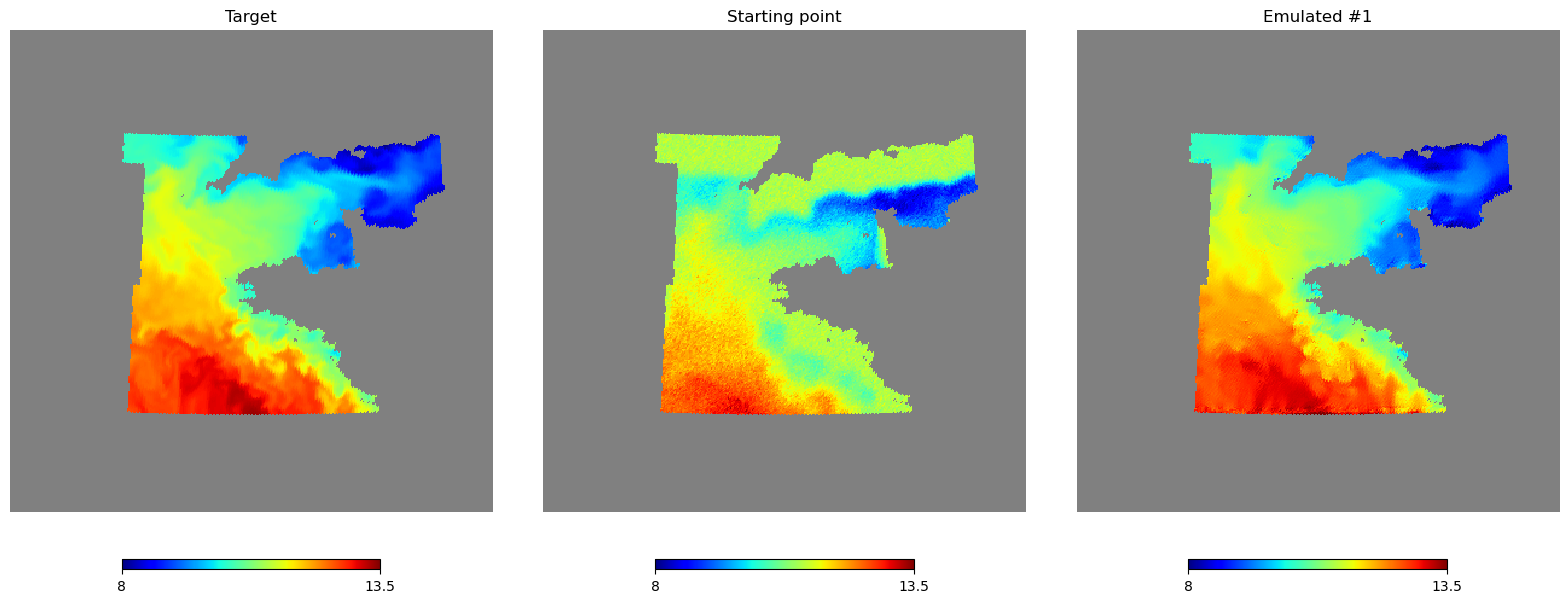

In [25]:
for k in range(min(2, N_MAPS)):
    plt.figure(figsize=(16, 6))
    plot_patch(field + median, sub=(1, 3, 1), title="Target", vmin=8, vmax=13.5)
    plot_patch(initial[k] + median, sub=(1, 3, 2), title="Starting point",
               vmin=8, vmax=13.5)
    plot_patch(emulated[k] + median, sub=(1, 3, 3), title="Emulated #%d" % k,
               vmin=8, vmax=13.5)
    plt.show()

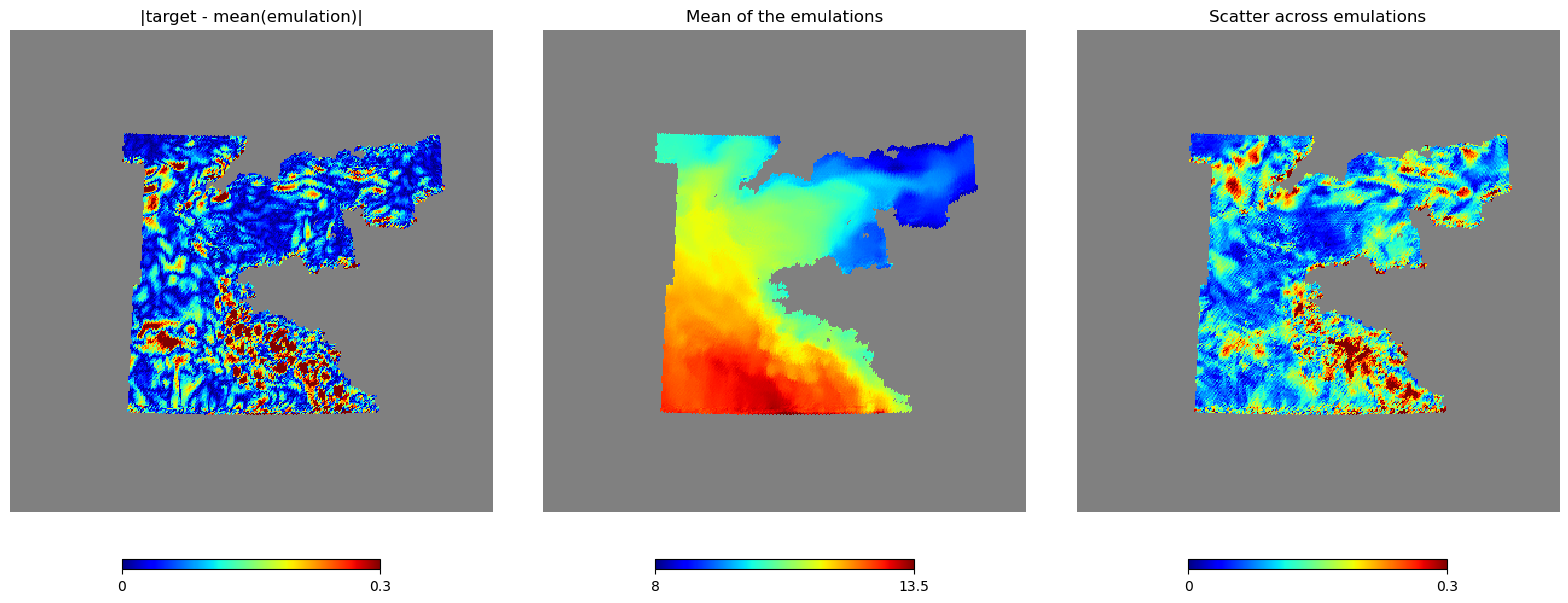

In [26]:
mean_emulated = emulated.mean(0)
std_emulated = emulated.std(0)

plt.figure(figsize=(16, 6))
plot_patch(np.abs(mean_emulated - field), sub=(1, 3, 1), vmin=0, vmax=0.3,
           title="|target - mean(emulation)|")
plot_patch(mean_emulated + median, sub=(1, 3, 2), vmin=8, vmax=13.5,
           title="Mean of the emulations")
plot_patch(std_emulated, sub=(1, 3, 3), vmin=0, vmax=0.3,
           title="Scatter across emulations")
plt.show()

### Is the scatter honest?

Three diagnostics, following the original:

* the distribution of the residuals, emulated and initial, against the target;
* the error of the mean against the scatter across members — an emulator whose
  scatter is meaningful should sit near the diagonal, not far above it;
* the residuals divided by the scatter, which should look standard normal if the
  spread is neither over- nor under-confident.

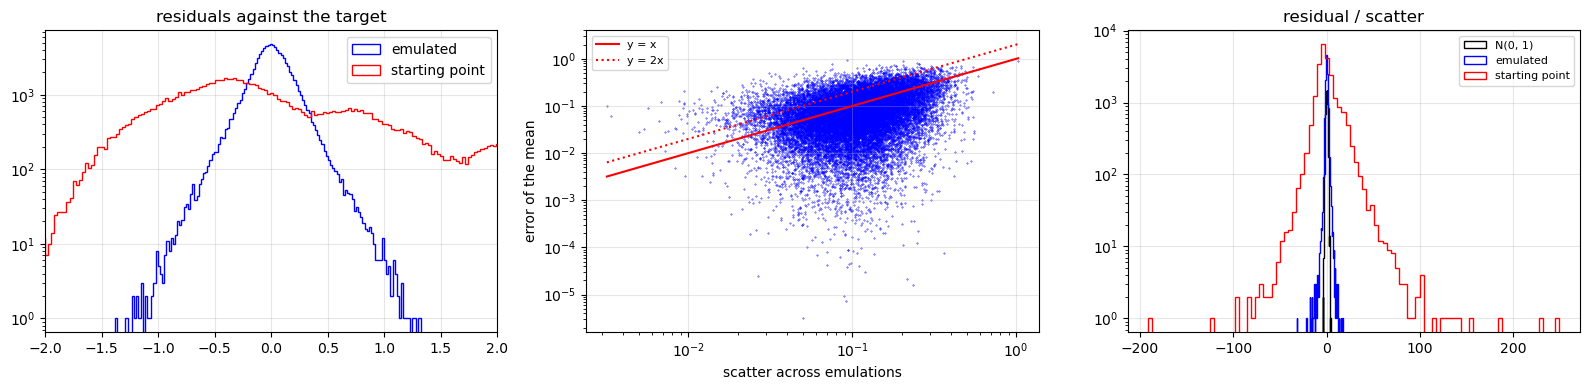

std   target 1.2577 | emulated 1.2574
residual / scatter: mean -0.002, std 1.48
a calibrated ensemble would give ~0 and ~1; with 4 members and 200 iterations
the spread is still under-dispersed -- the original demo used 40 maps, 500 epochs


In [27]:
plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
plt.hist((emulated - field).flatten(), bins=200, color="b", histtype="step",
         label="emulated")
plt.hist((initial - field).flatten(), bins=200, color="r", histtype="step",
         label="starting point")
plt.yscale("log"); plt.xlim(-2, 2); plt.legend(); plt.grid(alpha=.3)
plt.title("residuals against the target")

plt.subplot(1, 3, 2)
plt.scatter(std_emulated, np.abs(mean_emulated - field), color="b", s=0.1)
lo, hi = std_emulated.min(), std_emulated.max()
plt.plot([lo, hi], [lo, hi], color="r", label="y = x")
plt.plot([lo, hi], [2 * lo, 2 * hi], ":", color="r", label="y = 2x")
plt.xscale("log"); plt.yscale("log"); plt.legend(fontsize=8); plt.grid(alpha=.3)
plt.xlabel("scatter across emulations"); plt.ylabel("error of the mean")

plt.subplot(1, 3, 3)
plt.hist(np.random.randn(2 * field.size), bins=100, color="black",
         histtype="step", label="N(0, 1)")
plt.hist((mean_emulated - field) / std_emulated, bins=100, color="b",
         histtype="step", label="emulated")
plt.hist((initial.mean(0) - field) / std_emulated, bins=100, color="r",
         histtype="step", label="starting point")
plt.yscale("log"); plt.legend(fontsize=8); plt.grid(alpha=.3)
plt.title("residual / scatter")

plt.tight_layout(); plt.show()

ratio = (mean_emulated - field) / std_emulated
print("std   target %.4f | emulated %.4f" % (field.std(), emulated.std(axis=1).mean()))
print("residual / scatter: mean %+.3f, std %.2f" % (ratio.mean(), ratio.std()))
print("a calibrated ensemble would give ~0 and ~1; with %d members and %d iterations"
      % (N_MAPS, MAX_ITER))
print("the spread is still under-dispersed -- the original demo used 40 maps, 500 epochs")

## Where to go from here

* `NSIDE`, `J` and `L` set the resolution and the depth of the analysis; the
  cost of the convolution geometry grows linearly with the number of cells.
* `N_MAPS` and `MAX_ITER` set the emulation cost. More members give a more
  meaningful scatter; more iterations bring the statistics closer.
* On a full sky the angular power spectrum can join the loss
  (`compute_PS=True`), and it is worth it — see
  `tests/certification_notebooks/Healpix_Kernel_Torch/`.
* Data with holes are supported: feed a field with `NaN` and the operator
  infers the mask, propagates it scale by scale, and keeps the statistics
  unbiased over what remains.